In [1]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt


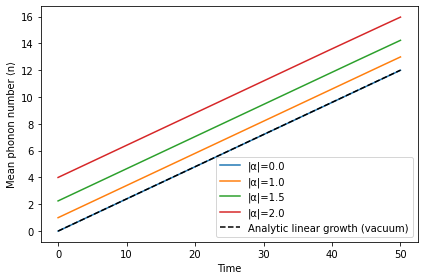

In [12]:
# --- Parameters ---
N = 100          # Fock cutoff
kappa = 0.24     # linear heating rate (d<n>/dt = kappa)
tmax = 50.0
num_steps = 600

# --- Operators ---
a = destroy(N)
adag = a.dag()
n_op = adag * a

# Zero Hamiltonian
H = 0 * n_op

# Dissipator: κ[D[a]] + κ[D[a†]]
c_ops = [np.sqrt(kappa) * a, np.sqrt(kappa) * adag]

# Time grid
tlist = np.linspace(0.0, tmax, num_steps)

# Initial coherent states to test
alphas = [0.0, 1.0, 1.5, 2.0]
colors = ['C0', 'C1', 'C2', 'C3']

plt.figure()

for alpha, color in zip(alphas, colors):
    psi0 = coherent(N, alpha)  # initial coherent state |α>
    result = mesolve(H, psi0, tlist, c_ops=c_ops, e_ops=[n_op])
    n_t = result.expect[0]
    plt.plot(tlist, n_t, color=color, label=f"|α|={alpha}")

# Analytic linear growth for vacuum case
n_analytic = 0.0 + kappa * tlist
plt.plot(tlist, n_analytic, 'k--', label="Analytic linear growth (vacuum)")

# Labels and formatting
plt.xlabel("Time")
plt.ylabel("Mean phonon number ⟨n⟩")
plt.legend()
plt.tight_layout()
plt.show()